<i>## Comments will be provided using this format. Key takeaway: groups are encouraged to change the formatting, but not the structure. Groups are also allowed to create additional notebooks - for instance, create one notebook for data exploration, and one notebook for each preprocessing-modelling-evaluation pipeline -, but must strive to keep an unified style across notebooks.</i>

#### NOVA IMS / BSc in Data Science / Text Mining 2025/2026
### <b>Group Project: "Straining the great southern Melting Pot"</b>
#### Notebook `Notebook Title`

#### Group:
- `Group member #1`
- `(...)`
- `Group member #5`

#### <font color='#BFD72'>Table of Contents </font> <a class="anchor" id='toc'></a> 
- [1. Data Understanding](#P1)
- [2. General Data Preparation](#P2) 
- [3. Multilabel Classification (Information Requirement 3311)](#P3)
    - [3.1 Specific Data Preparation](#P31)
    - [3.2 Model Implementation](#P32)
    - [3.3 Model Evaluation](#P3n)
- [4. Sentiment Analysis (Information Requirement 3312)](#P4)
    - [4.1 Specific Data Preparation](#P41)
    - [4.2 Model Implementation](#P42)
    - [4.3 Model Evaluation](#P43)
- [...]
- [N. Additional Tasks (Information Requirements 332n)](#Pn)
    - [N.1 Specific Data Preparation](#Pn1)
    - [N.2 Model Implementation](#Pn2)
    - [N.3 Model Evaluation](#Pn3)

<i>## Note that the notebook structure differs from the report: instead of following the CRISP-DM phases and then specifying the different problems inside the phases, the notebook is structured by problem, with the CRISP-DM phases being defined for each specific problem.

In [2]:
## All imports must be concentrated on a cell that immediately follow the table of contents
import time
import pandas as pd

<font color='#BFD72F' size=5>1. Data Understanding</font> <a class="anchor" id="P1"></a>
  
[Back to TOC](#toc)


Let's start buy reading the dataset

<font color='#BFD72F' size=5>2. Data Preprocessing</font> <a class="anchor" id="P1"></a>
  
[Back to TOC](#toc)

<i>## Use markdown cells to describe the purpose of the code cells that follow them.</i>

In [23]:
import pandas as pd
import re
import unicodedata
import nltk
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import seaborn as sns




In [4]:
atlanta_rest = pd.read_csv("data_atlanta/atlanta_restaurant_slice_2023.csv", header=0)
atlanta_rest

,title,categoryName,website,url,reviewsCount,stars,text
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr..."
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...
...,...,...,...,...,...,...,...
53561,L On North,New American restaurant,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Friday night dinner was Chicken Francaise. Jor...
53562,L On North,New American restaurant,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Great dinner.... Yay Jordan!!!!!!
53563,L On North,New American restaurant,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Jordan was our server and he was fantastic! Gr...
53564,L On North,New American restaurant,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Jordan was an amazing server! Great delicious...


In [3]:
atlanta_rest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53566 entries, 0 to 53565
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         53566 non-null  object 
 1   categoryName  53566 non-null  object 
 2   website       50600 non-null  object 
 3   url           53566 non-null  object 
 4   reviewsCount  53566 non-null  int64  
 5   stars         53566 non-null  float64
 6   text          53566 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 2.9+ MB


In [5]:
# Drop duplicates and rows without review text
atlanta_rest.drop_duplicates(subset=["text"], inplace=True)
atlanta_rest.dropna(subset=["text"], inplace=True)

In [6]:
# Drop the unneeded columns, rename the 'text' column to 'raw_text', and change its data type to 'string'.
atlanta_rest = atlanta_rest.drop(columns=["website","url"])
atlanta_rest = atlanta_rest.rename(columns={"text":"raw_content"})
atlanta_rest["raw_content"] = atlanta_rest["raw_content"].astype(str)
atlanta_rest.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51542 entries, 0 to 53565
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         51542 non-null  object 
 1   categoryName  51542 non-null  object 
 2   reviewsCount  51542 non-null  int64  
 3   stars         51542 non-null  float64
 4   raw_content   51542 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 2.4+ MB


Number of Reviews per Restaurant:
Minimum: 8
Maximum: 1075
Average: 174.72


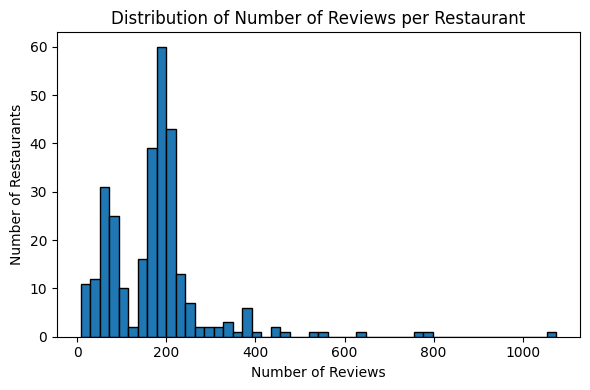

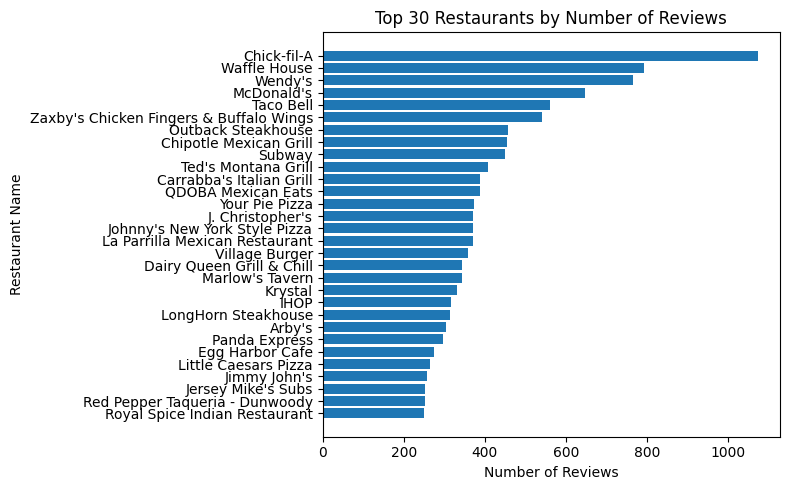

In [30]:
# === 1) GROUP AND COMPUTE REVIEW COUNTS ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Group reviews per restaurant into a dictionary: {restaurant_title: [list_of_reviews]}
reviews_per_restaurant = (
    atlanta_rest
    .groupby('title')['raw_content']
    .apply(list)
    .to_dict()
)

# Convert dictionary to a Pandas Series with counts
# This gives us: {restaurant_title: number_of_reviews}
counts_per_restaurant = (
    pd.Series({k: len(v) for k, v in reviews_per_restaurant.items()}, name='n_reviews')
    .sort_values(ascending=False)
)

# Convert to DataFrame for easier handling
counts_df = counts_per_restaurant.reset_index().rename(columns={'index': 'title'})

# Extract the counts array for statistics
num_reviews_per_restaurant = counts_df['n_reviews'].values

# Print basic descriptive statistics
print("Number of Reviews per Restaurant:")
print(f"Minimum: {np.min(num_reviews_per_restaurant)}")
print(f"Maximum: {np.max(num_reviews_per_restaurant)}")
print(f"Average: {np.mean(num_reviews_per_restaurant):.2f}")

# === 2) HISTOGRAM OF REVIEW DISTRIBUTION ===
plt.figure(figsize=(6, 4))
plt.hist(num_reviews_per_restaurant, bins=50, edgecolor='black')
plt.title('Distribution of Number of Reviews per Restaurant')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Restaurants')

# Uncomment this if the histogram is too skewed (long tail)
# plt.yscale('log')

plt.tight_layout()
plt.show()

# === 3) BAR CHART OF TOP-N RESTAURANTS ===
TOP_N = 30  # Choose how many restaurants to display
topN = counts_df.head(TOP_N)

plt.figure(figsize=(8, 5))
# Reverse the order so the bar chart goes from smallest to biggest from top to bottom (looks nicer)
plt.barh(topN['title'][::-1], topN['n_reviews'][::-1])
plt.title(f'Top {TOP_N} Restaurants by Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Restaurant Name')
plt.tight_layout()
plt.show()


In [31]:
atlanta_rest.sample(5)

,title,categoryName,reviewsCount,stars,raw_content,has_accent,has_symbol,has_emoji,clean_text,tokenised_content,pos_tags,norm_tokens,processed_text
19652,Popeyes Louisiana Kitchen,Chicken restaurant,954,1.0,If I could Give this location zero stars that ...,True,False,False,if i could give this location zero stars that ...,"[if, i, could, give, this, location, zero, sta...","[IN, NNS, MD, VB, DT, NN, CD, NNS, WDT, MD, VB...","[could, give, location, zero, star, would, com...",could give location zero star would compliment...
703,5Church Buckhead,New American restaurant,449,4.0,Cool place. Good food,False,False,False,cool place good food,"[cool, place, good, food]","[JJ, NN, JJ, NN]","[cool, place, good, food]",cool place good food
5931,Blue Moon Pizza Sandy Springs,Pizza restaurant,1024,5.0,Best pizza Cheeseburger Pizza,False,False,False,best pizza cheeseburger pizza,"[best, pizza, cheeseburger, pizza]","[JJS, NN, NN, NN]","[best, pizza, cheeseburger, pizza]",best pizza cheeseburger pizza
23657,El Rio Cantina,Mexican restaurant,455,1.0,"Great food, shame it took 38 minutes to get my...",True,False,False,great food shame it took minutes to get my ord...,"[great, food, shame, it, took, minutes, to, ge...","[JJ, NN, NN, PRP, VBD, NNS, TO, VB, PRP$, NN, ...","[great, food, shame, took, minute, get, order,...",great food shame took minute get order waiter ...
14435,Waffle House,Breakfast restaurant,779,5.0,Very friendly staff ...daytime visit...place w...,False,False,False,very friendly staff daytime visit place was cl...,"[very, friendly, staff, daytime, visit, place,...","[RB, JJ, NN, JJ, NN, NN, VBD, JJ, NN, JJ, JJ, ...","[friendly, staff, daytime, visit, place, clean...",friendly staff daytime visit place clean food ...


       reviewsCount         stars
count  51542.000000  51542.000000
mean     922.828761      4.025979
std     1139.628413      1.463805
min        5.000000      1.000000
25%      404.000000      3.000000
50%      648.000000      5.000000
75%     1053.000000      5.000000
max    13268.000000      5.000000
              reviewsCount     stars
reviewsCount      1.000000  0.028316
stars             0.028316  1.000000


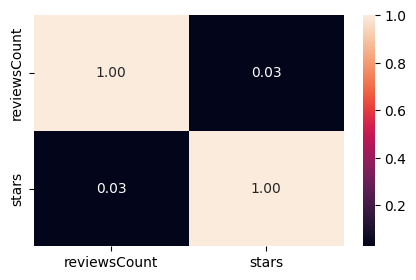

In [26]:


from matplotlib import pyplot as plt

print(atlanta_rest.describe())

numeric_atlanta_rest = atlanta_rest.select_dtypes(include=['int64', 'float64'])
corr = numeric_atlanta_rest.corr()
print(corr)

plt.figure(figsize=(5,3))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.show()

We do not have correlation between stars and review count.

In [34]:
atlanta_rest['categoryName'].nunique()


19

                categoryName  n_restaurants
0         Mexican restaurant             52
1        American restaurant             36
2         Italian restaurant             30
3           Pizza restaurant             23
4         Chinese restaurant             16
5       Fast food restaurant             16
6    New American restaurant             15
7         Seafood restaurant             15
8       Hamburger restaurant             11
9          Indian restaurant              9
10       Japanese restaurant              9
11  Mediterranean restaurant              9
12           Thai restaurant              9
13      Breakfast restaurant              8
14        Chicken restaurant              8
15             Sandwich shop              8
16               Steak house              8
17               Bar & grill              7
18       Barbecue restaurant              7


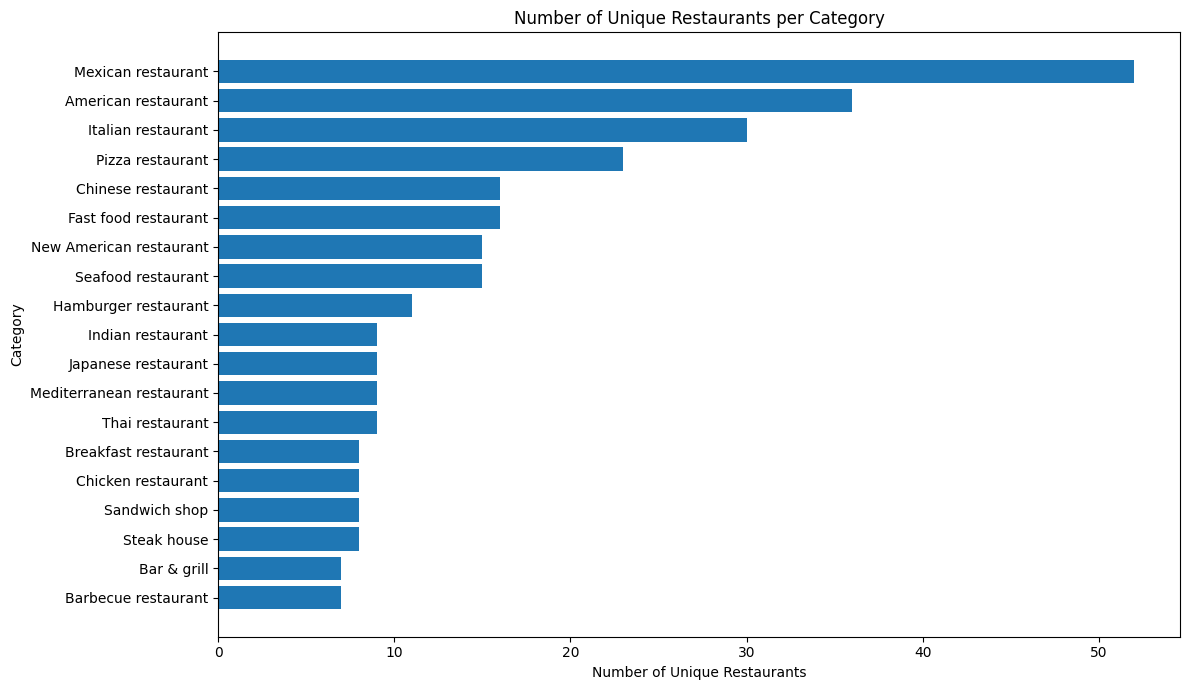

In [37]:
# === COUNT UNIQUE RESTAURANTS PER CATEGORY (ALL CATEGORIES) ===
import pandas as pd
import matplotlib.pyplot as plt

# Count unique restaurants per category
restaurants_per_category = (
    atlanta_rest
    .groupby('categoryName')['title']
    .nunique()
    .sort_values(ascending=False)
)

# Print the result as a table
restaurants_per_category_df = restaurants_per_category.reset_index()
restaurants_per_category_df.columns = ['categoryName', 'n_restaurants']
print(restaurants_per_category_df)

# Plot bar chart for all categories
plt.figure(figsize=(12, 7))
plt.barh(restaurants_per_category.index[::-1], restaurants_per_category.values[::-1])
plt.title('Number of Unique Restaurants per Category')
plt.xlabel('Number of Unique Restaurants')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


In [8]:
print("Columns after cleaning:", atlanta_rest.columns.tolist())

Columns after cleaning: ['title', 'categoryName', 'reviewsCount', 'stars', 'raw_content']


In [9]:
# Check and count accents, symbols, and emojis in the reviews
accent_pattern = re.compile(r"[^\x00-\x7F]")  # detects non-ASCII (accents & special Unicode)
symbol_pattern = re.compile(r"[\u2600-\u26FF\u2700-\u27BF]")  # symbols, dingbats
emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map
                           u"\U0001F1E0-\U0001F1FF"  # flags
                           "]+", flags=re.UNICODE)

def has_accent(text):
    return bool(accent_pattern.search(str(text)))

def has_symbol(text):
    return bool(symbol_pattern.search(str(text)))

def has_emoji(text):
    return bool(emoji_pattern.search(str(text)))

# Checks and counts
atlanta_rest["has_accent"] = atlanta_rest["raw_content"].apply(has_accent)
atlanta_rest["has_symbol"] = atlanta_rest["raw_content"].apply(has_symbol)
atlanta_rest["has_emoji"] = atlanta_rest["raw_content"].apply(has_emoji)

print("Accents:", atlanta_rest["has_accent"].sum(), f"({atlanta_rest['has_accent'].mean():.2%})")
print("Symbols:", atlanta_rest["has_symbol"].sum(), f"({atlanta_rest['has_symbol'].mean():.2%})")
print("Emojis:", atlanta_rest["has_emoji"].sum(), f"({atlanta_rest['has_emoji'].mean():.2%})")


Accents: 7434 (14.42%)
Symbols: 355 (0.69%)
Emojis: 0 (0.00%)


In [11]:
def clean_text(text):
    """
    Basic text cleaning:
    - lowercasing
    - remove URLs, HTML, mentions, hashtags
    - remove non-letter characters and extra spaces
    """
    text = str(text).lower()                          # Lowercase
    text = re.sub(r"http\S+|www\S+", "", text)        # Remove URLs
    text = re.sub(r"<.*?>", "", text)                 # Remove HTML tags
    text = re.sub(r"@\w+", "", text)                  # Remove @mentions
    text = re.sub(r"#\w+", "", text)                  # Remove hashtags
    text = re.sub(r"[^a-z\s]", " ", text)             # Keep letters only
    text = re.sub(r"\s+", " ", text).strip()          # Remove extra spaces
    text = unicodedata.normalize('NFKD', text)        # Normalize unicode
    text = text.encode('ascii', 'ignore').decode('utf-8')
    punctuation_pattern = r"[\u0021-\u002F\u003A-\u003F\u005B-\u005F\u2010-\u2028]+" # Remove punctuation
    text = re.sub(punctuation_pattern, " ", text)
    
    text = re.sub(r"[^a-z\s]", " ", text)       # Keep letters only (remove emojis and special symbols)
    return text

In [12]:
# Apply the cleaning function
atlanta_rest["clean_text"] = atlanta_rest["raw_content"].apply(clean_text)

In [12]:
atlanta_rest

,title,categoryName,reviewsCount,stars,raw_content,has_accent,has_symbol,has_emoji,clean_text
0,The Optimist,Seafood restaurant,3349,5.0,"One word amazing!! The red fish, halibut, fr...",False,False,False,one word amazing the red fish halibut fried ri...
1,The Optimist,Seafood restaurant,3349,5.0,First time here and the food is great and the ...,False,False,False,first time here and the food is great and the ...
2,The Optimist,Seafood restaurant,3349,5.0,I recently had the pleasure of dining at Optim...,False,False,False,i recently had the pleasure of dining at optim...
3,The Optimist,Seafood restaurant,3349,5.0,Beautiful atmosphere and delicious food. All o...,True,False,False,beautiful atmosphere and delicious food all of...
4,The Optimist,Seafood restaurant,3349,5.0,We had a wonderful dinner at the Optimist. Our...,False,False,False,we had a wonderful dinner at the optimist our ...
...,...,...,...,...,...,...,...,...,...
53561,L On North,New American restaurant,449,5.0,Friday night dinner was Chicken Francaise. Jor...,False,False,False,friday night dinner was chicken francaise jord...
53562,L On North,New American restaurant,449,5.0,Great dinner.... Yay Jordan!!!!!!,False,False,False,great dinner yay jordan
53563,L On North,New American restaurant,449,5.0,Jordan was our server and he was fantastic! Gr...,False,False,False,jordan was our server and he was fantastic gre...
53564,L On North,New American restaurant,449,5.0,Jordan was an amazing server! Great delicious...,False,False,False,jordan was an amazing server great delicious m...


Tokenisation

In [13]:
nltk.download('punkt_tab')
atlanta_rest["tokenised_content"] = atlanta_rest["clean_text"].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/viktoria/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [14]:
nltk.download('averaged_perceptron_tagger_eng')
atlanta_rest['pos_tags'] = atlanta_rest['tokenised_content'].apply(lambda tokens : [pos[1] for pos in pos_tag(tokens)])


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/viktoria/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [22]:
atlanta_rest

,title,categoryName,reviewsCount,stars,raw_content,has_accent,has_symbol,has_emoji,clean_text,tokenised_content,pos_tags
0,The Optimist,Seafood restaurant,3349,5.0,"One word amazing!! The red fish, halibut, fr...",False,False,False,one word amazing the red fish halibut fried ri...,"[one, word, amazing, the, red, fish, halibut, ...","[CD, NN, VBG, DT, JJ, NN, NN, VBD, NN, CC, NN,..."
1,The Optimist,Seafood restaurant,3349,5.0,First time here and the food is great and the ...,False,False,False,first time here and the food is great and the ...,"[first, time, here, and, the, food, is, great,...","[JJ, NN, RB, CC, DT, NN, VBZ, JJ, CC, DT, NN, ..."
2,The Optimist,Seafood restaurant,3349,5.0,I recently had the pleasure of dining at Optim...,False,False,False,i recently had the pleasure of dining at optim...,"[i, recently, had, the, pleasure, of, dining, ...","[NN, RB, VBD, DT, NN, IN, VBG, IN, NN, IN, JJ,..."
3,The Optimist,Seafood restaurant,3349,5.0,Beautiful atmosphere and delicious food. All o...,True,False,False,beautiful atmosphere and delicious food all of...,"[beautiful, atmosphere, and, delicious, food, ...","[NN, RB, CC, JJ, NN, DT, IN, DT, NN, NN, NN, I..."
4,The Optimist,Seafood restaurant,3349,5.0,We had a wonderful dinner at the Optimist. Our...,False,False,False,we had a wonderful dinner at the optimist our ...,"[we, had, a, wonderful, dinner, at, the, optim...","[PRP, VBD, DT, JJ, NN, IN, DT, JJ, PRP$, NN, I..."
...,...,...,...,...,...,...,...,...,...,...,...
53561,L On North,New American restaurant,449,5.0,Friday night dinner was Chicken Francaise. Jor...,False,False,False,friday night dinner was chicken francaise jord...,"[friday, night, dinner, was, chicken, francais...","[JJ, NN, NN, VBD, VBN, RB, NN, VBD, DT, JJ, NN..."
53562,L On North,New American restaurant,449,5.0,Great dinner.... Yay Jordan!!!!!!,False,False,False,great dinner yay jordan,"[great, dinner, yay, jordan]","[JJ, NN, NNS, NN]"
53563,L On North,New American restaurant,449,5.0,Jordan was our server and he was fantastic! Gr...,False,False,False,jordan was our server and he was fantastic gre...,"[jordan, was, our, server, and, he, was, fanta...","[NN, VBD, PRP$, NN, CC, PRP, VBD, JJ, JJ, NN]"
53564,L On North,New American restaurant,449,5.0,Jordan was an amazing server! Great delicious...,False,False,False,jordan was an amazing server great delicious m...,"[jordan, was, an, amazing, server, great, deli...","[NN, VBD, DT, JJ, NN, JJ, JJ, NN, CC, VB, JJ, ..."


Remove Stopwords

In [39]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = stopwords.words('english')
print(stop_words)
print(len(stop_words))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/viktoria/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


We analyse word clouds per category and decided to delete additional stopwords related to the restorant and food domain. You can see pictures of the word clouds before additional stopwords in the "wordclouds_by_category_before_removing_additional_stopwords" folder.

In [49]:
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words("english"))

# Add domain-specific stopwords
extra_stopwords = {
    'food','restaurant','restaurants','place','menu','order','ordered','service','staff',
    'like','really','also','just','one','get','got','time','day','night','visit','visited',
    'good','great','nice','amazing','awesome','best','love','loved','delicious','tasty',
    'atlanta','buckhead','downtown','midtown','amp', 'always', 'excellent', 'great', 'experience', 'go', 'customer', 'location', 'friendly', 'table', 'back', 'try', 'tried'
}
stop_words = stop_words.union(extra_stopwords)

lemmatizer = WordNetLemmatizer()

def normalise_tokens(tokens):
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

atlanta_rest["norm_tokens"] = atlanta_rest["tokenised_content"].apply(normalise_tokens)
atlanta_rest["processed_text"] = atlanta_rest["norm_tokens"].apply(lambda x: " ".join(x))


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/viktoria/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/viktoria/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [44]:
atlanta_rest['norm_tokens']

0        [word, red, fish, halibut, fried, rice, brocco...
1                        [first, great, waiter, excellent]
2        [recently, pleasure, dining, optimist, atlanta...
3        [beautiful, atmosphere, flavorful, overall, gr...
4        [wonderful, dinner, optimist, group, great, me...
                               ...                        
53561    [friday, dinner, chicken, francaise, jordan, e...
53562                         [great, dinner, yay, jordan]
53563             [jordan, server, fantastic, great, meal]
53564    [jordan, server, great, meal, wine, social, di...
53565      [great, well, spaced, table, live, music, back]
Name: norm_tokens, Length: 51542, dtype: object

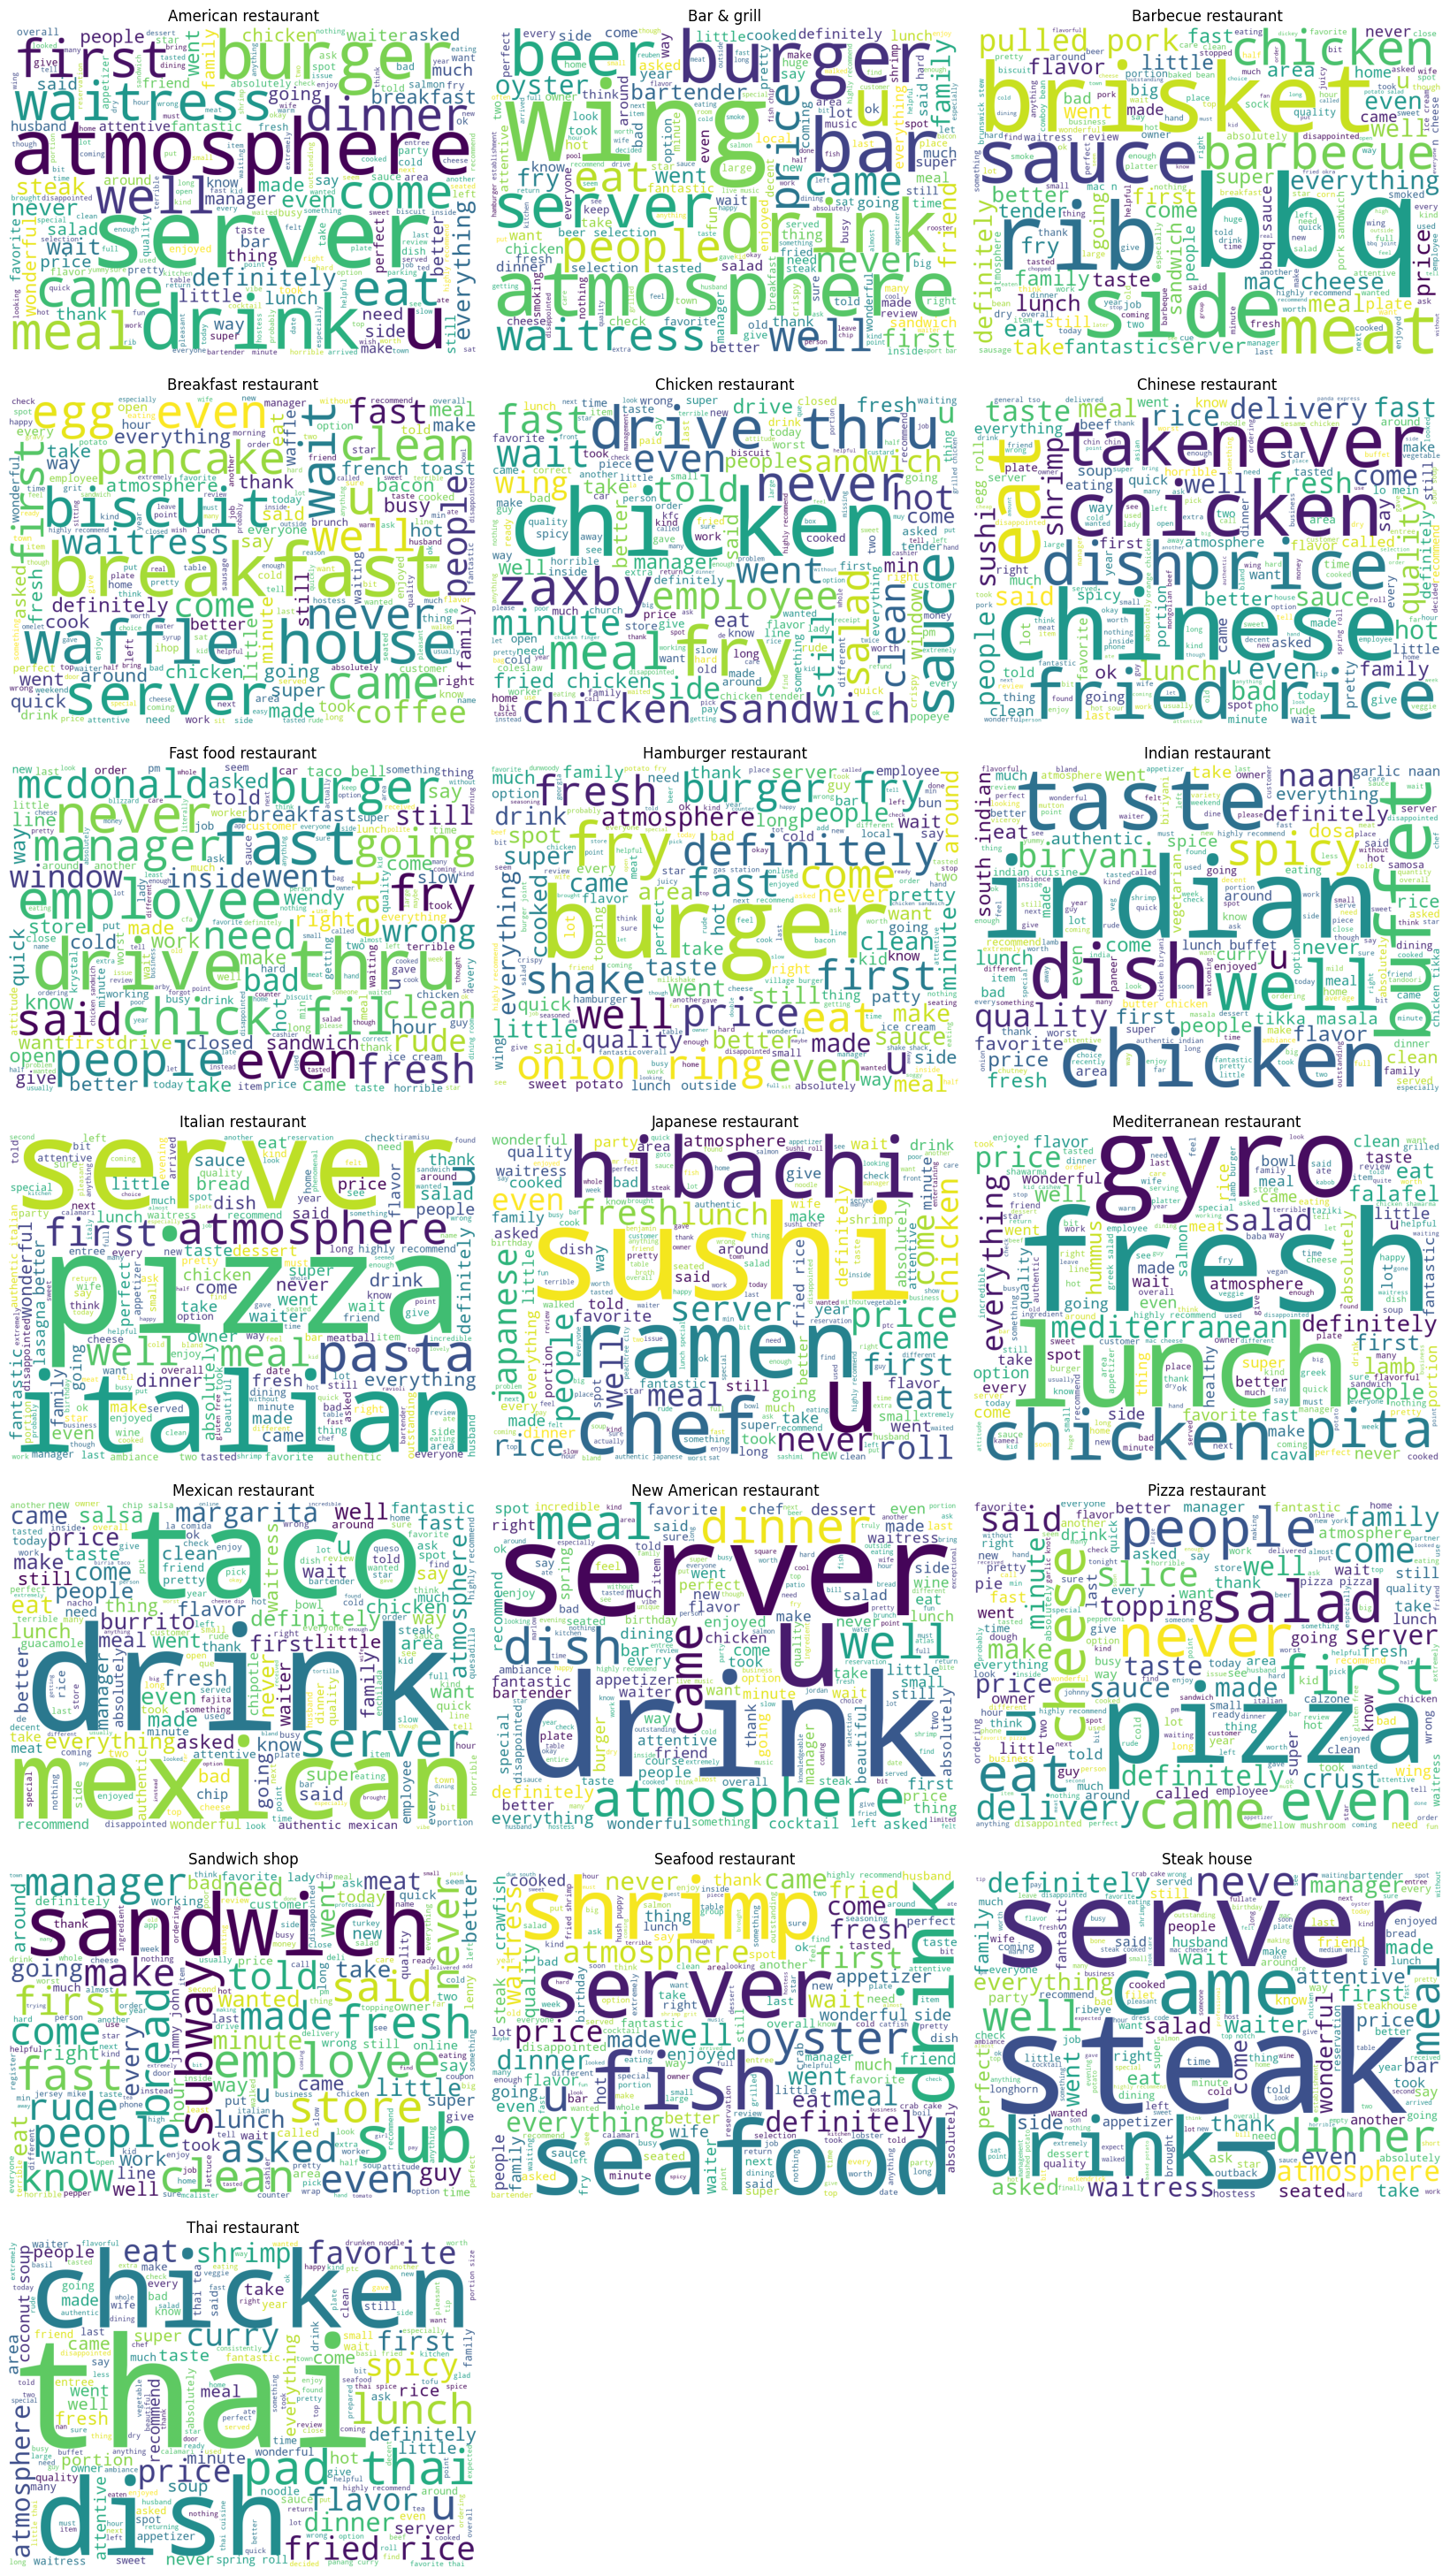

In [52]:
import os
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# group all processed text by category
texts_by_cat = (
    atlanta_rest
      .groupby("categoryName")["processed_text"]
      .apply(lambda s: " ".join(s))
      .to_dict()
)

os.makedirs("wordclouds", exist_ok=True)

# generate + save
for cat, text in texts_by_cat.items():
    wc = WordCloud(width=1000, height=700, background_color="white").generate(text)
    wc.to_file(f"wordclouds/{cat}.png")

# show all in grid
cats = list(texts_by_cat.keys())
n = len(cats)
cols = 3
rows = (n + cols - 1) // cols

plt.figure(figsize=(5.5*cols, 4.2*rows))
i = 1
for cat in cats:
    img = plt.imread(f"wordclouds/{cat}.png")
    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(cat)
    i += 1
plt.tight_layout()
plt.show()
